In [24]:
import matplotlib.pyplot as plt
import numpy as np

In [27]:
def bond_price(face_value, coupon_rate, ttm, market_rate, n_periods=1):
    periods = ttm * n_periods
    coupon = face_value * (coupon_rate / n_periods)
    r = market_rate / n_periods
    total_coupons = 0
    for i in range(1, periods + 1):
        current = coupon / ((1 + r)**i)
        total_coupons += current
    pvfv = face_value / ((1 + r)**periods)
    price = total_coupons + pvfv
    return price
bond_price(1000, 0.06, 10, 0, 1)


1600.0

In [29]:
def solve_ytm(price, face, coupon_rate, ttm, n_periods=1):
    low = 0.0001
    high = 1.0
    for x in range(100):
        mid = (low + high) / 2
        val = bond_price(face, coupon_rate, ttm, mid, n_periods)
        if val > price:
            low = mid
        else:
            high = mid
    return mid
solve_ytm(1600, 1000, 0.06, 10)

0.00010000000000000002

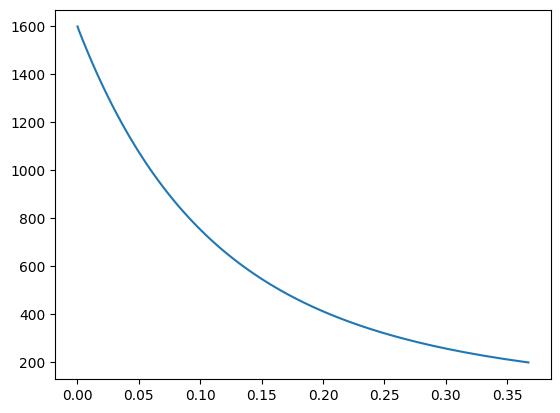

In [34]:
price_values = np.linspace(200, 1600, 100)
ytms = []
for price in price_values:
    ytm = solve_ytm(price, 1000, 0.06, 10, 1)
    ytms.append(ytm)
plt.plot(ytms, price_values)

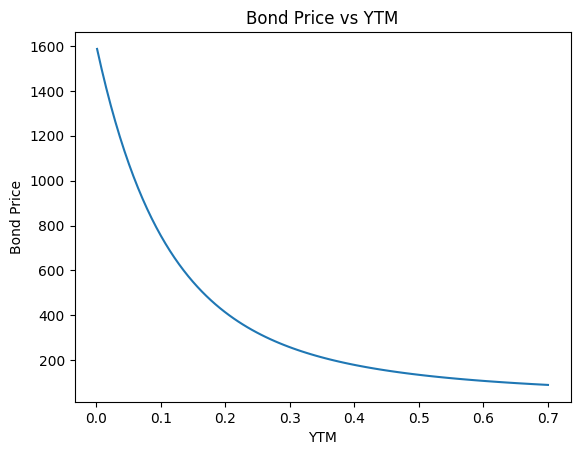

In [ ]:
ytm_values = np.linspace(0.001, 0.70, 100)
prices = []
for ytm in ytm_values:
    price = bond_price(1000, 0.06, 10, ytm, 1)
    prices.append(price)
plt.plot(ytm_values, prices)
plt.xlabel("YTM")
plt.ylabel("Bond Price")
plt.title("Bond Price vs YTM")
plt.show()